Prototype CNN
Sahil Mulki

In [1]:
# Run once to install dependencies.
%pip install torch torchvision matplotlib opencv-python python-dotenv kaggle

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import cv2
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

In [3]:
SEED = 42
torch.manual_seed(SEED)

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

DATA_DIR = "brain_mri_dataset"
TRAIN_DIR = os.path.join(DATA_DIR, "Training")
TEST_DIR = os.path.join(DATA_DIR, "Testing")

IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-3

In [ ]:
from dotenv import load_dotenv


load_dotenv(dotenv_path=os.path.join("..", ".env"))
load_dotenv() 

if os.path.isdir(TRAIN_DIR) and os.path.isdir(TEST_DIR):
    print("Dataset already present")
else:
    import kaggle
    kaggle.api.authenticate()
    print("Downloading dataset from Kaggle (this may take a few minutes)...")
    kaggle.api.dataset_download_files(
        "masoudnickparvar/brain-tumor-mri-dataset",
        path=DATA_DIR,
        unzip=True,
    )
    print("Done.")

Dataset already present - skipping download.


In [ ]:
# Data augmentation
def crop_brain_region(pil_img):
    gray = np.array(pil_img.convert("L"))
    thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)[1]
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return pil_img
    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
    return pil_img.crop((x, y, x + w, y + h))

In [ ]:
transform = transforms.Compose([
    transforms.Lambda(crop_brain_region),
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

full_train = datasets.ImageFolder(TRAIN_DIR, transform=transform)
test_ds = datasets.ImageFolder(TEST_DIR, transform=transform)
class_names = full_train.classes

n_val = int(len(full_train) * 0.15)
train_ds, val_ds = random_split(
    full_train, [len(full_train) - n_val, n_val],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

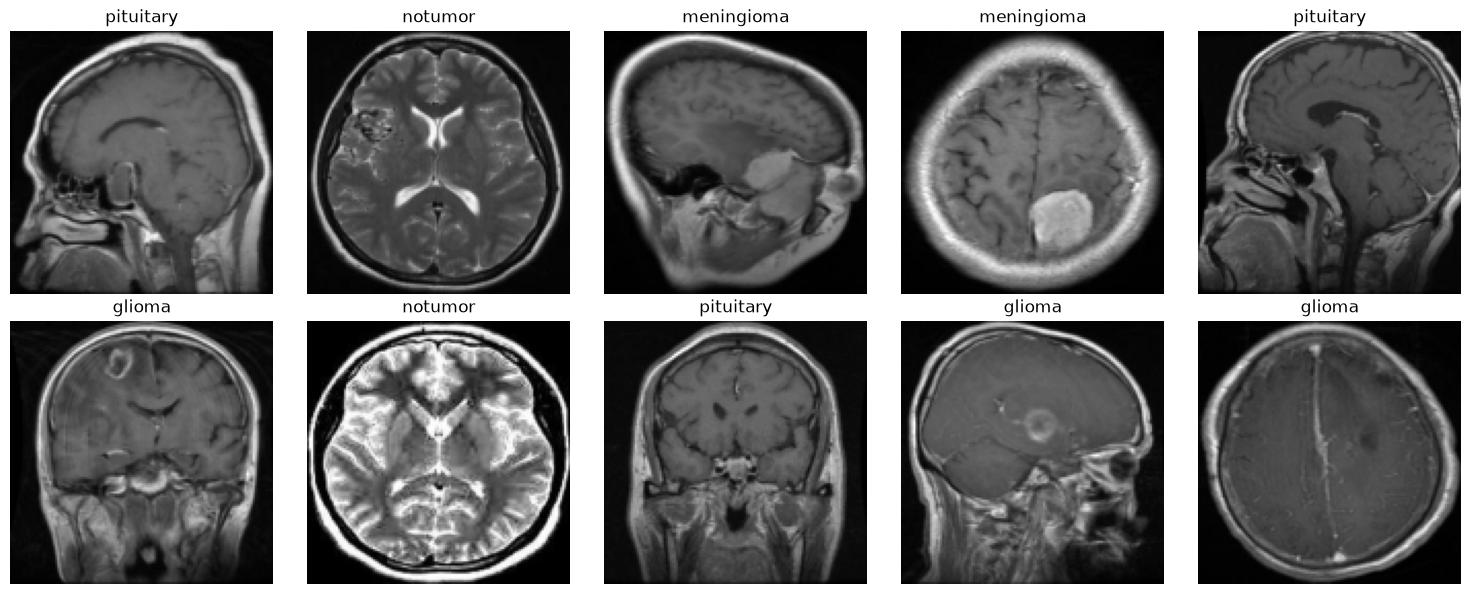

In [7]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for img, lbl, ax in zip(images[:10], labels[:10], axes.flatten()):
    ax.imshow(img.squeeze(0), cmap="gray")
    ax.set_title(class_names[lbl])
    ax.axis("off")
plt.tight_layout(); plt.show()

In [8]:
class CNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 16, 3), nn.ReLU(), nn.MaxPool2d(2),
        )
        with torch.no_grad():
            n_flat = self.conv(torch.zeros(1, 1, IMG_SIZE, IMG_SIZE)).flatten(1).shape[1]
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_flat, 128), nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.fc(self.conv(x))


model = CNN(num_classes=len(class_names)).to(DEVICE)

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses, val_accs = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            correct += (model(imgs).argmax(1) == labels).sum().item()
            total += labels.size(0)

    train_losses.append(epoch_loss / len(train_loader))
    val_accs.append(correct / total)
    print(f"Epoch {epoch}/{EPOCHS} | train loss {train_losses[-1]:.4f} | val acc {val_accs[-1]:.4f}")

Epoch 1/10 | train loss 0.9634 | val acc 0.7393
Epoch 2/10 | train loss 0.5847 | val acc 0.7810
Epoch 3/10 | train loss 0.4734 | val acc 0.8000
Epoch 4/10 | train loss 0.4026 | val acc 0.7952
Epoch 5/10 | train loss 0.3335 | val acc 0.8560
Epoch 6/10 | train loss 0.2755 | val acc 0.8571
Epoch 7/10 | train loss 0.2206 | val acc 0.8631
Epoch 8/10 | train loss 0.1823 | val acc 0.8512
Epoch 9/10 | train loss 0.1250 | val acc 0.8952
Epoch 10/10 | train loss 0.0942 | val acc 0.8857


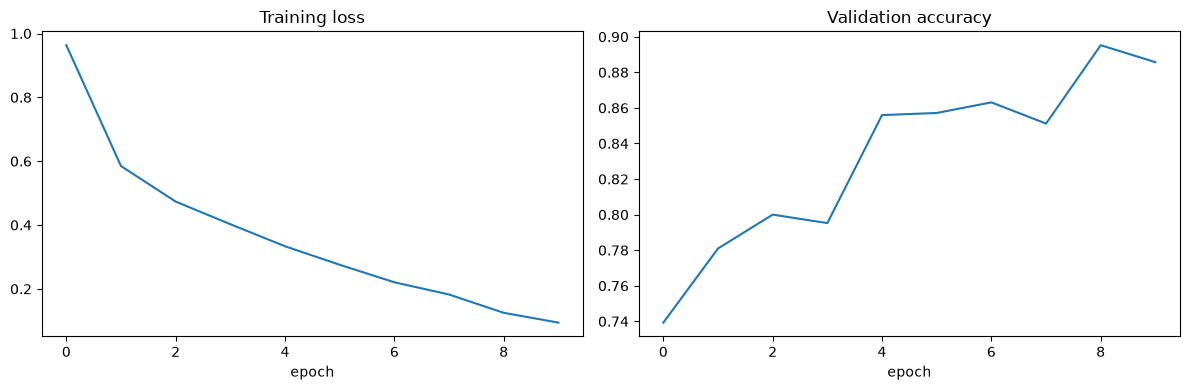

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(train_losses); ax[0].set_title("Training loss"); ax[0].set_xlabel("epoch")
ax[1].plot(val_accs); ax[1].set_title("Validation accuracy"); ax[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

## 7. Test accuracy

In [11]:
model.eval()
correct = total = 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        correct += (model(imgs).argmax(1) == labels).sum().item()
        total += labels.size(0)

print(f"Test accuracy: {correct / total:.4f}")

Test accuracy: 0.8669
